In [28]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import subprocess
import re
import math
from hta.trace_analysis import TraceAnalysis

# Configuration
ACCEL_FILE = "kernel_times2.csv"
TRACE_ROOT_DIR = "/proj/threadtune-PG0/amir/kineto_traces/"
CU_FILT_PATH = "/usr/local/cuda/bin/cu++filt"  # Update this path if needed

In [29]:
import polars as pl
import re
import subprocess

# --- 1. Robust Demangler ---
def demangle_names(df: pl.DataFrame, col_name: str, new_col_name: str = "demangled_name") -> pl.DataFrame:
    if col_name not in df.columns:
        return df

    mangled = df[col_name].fill_null("").to_list()
    if not mangled:
        return df.with_columns(pl.lit("").alias(new_col_name))

    try:
        # -p is CRITICAL. It tells c++filt to not display function parameters.
        # However, it doesn't always work on complex nested templates, 
        # so we will do extra cleaning in Python.
        process = subprocess.run(
            ["/usr/local/cuda/bin/cu++filt", "-p"], 
            input="\n".join(mangled), 
            text=True, 
            capture_output=True,
            check=True
        )
        demangled = process.stdout.strip().split("\n")
    except Exception as e:
        print(f"Warning: Demangling failed ({e}). Using original names.")
        demangled = mangled

    if len(demangled) != len(mangled):
        demangled = mangled

    return df.with_columns(pl.Series(name=new_col_name, values=demangled))

# --- 2. Nuclear Option Normalizer ---
def normalize_kernel_name(name: str) -> str:
    if not name:
        return ""
    
    s = name
    
    # 1. Remove all spaces (fixes "char *" vs "char*")
    s = s.replace(" ", "")
    
    # 2. Standardize Namespaces
    s = s.replace("(anonymousnamespace)", "<unnamed>")
    
    # 3. NORMALIZE LAMBDAS (Fixes your specific bloom issue)
    # Accel: [lambda(long) (instance 1)]
    # Kineto: {lambda(long)#1}
    # We replace the whole block with "LAMBDA"
    s = re.sub(r'\[lambda.*?\(instance\d+\)\]', 'LAMBDA', s) # Accel style
    s = re.sub(r'\{lambda.*?#\d+\}', 'LAMBDA', s)            # Kineto style
    
    # 4. Remove C-style casts inside templates
    # (int)4 -> 4, (unsigned long)1 -> 1
    s = re.sub(r'\((?:int|long|unsigned|unsignedlong|unsignedint|bool)\)', '', s)
    
    # 5. Remove numeric suffixes
    # 1ul -> 1, 4L -> 4
    s = re.sub(r'(\d+)[uU]?[lL]+', r'\1', s)
    
    # 6. Simplify std::string
    s = s.replace("std::basic_string<char>", "std::string")

    # 7. AGGRESSIVE: Strip Function Arguments
    # Your data shows Accel has "(int, T2, T3)" while Kineto has "(int, FillFunctor...)"
    # We strip the very last (...) block if it exists.
    # We look for a closing parenthesis at the end of the string, and remove up to its matching open.
    # Note: This regex removes the last parentheses group.
    s = re.sub(r'\([^)]*\)$', '', s)

    # 8. Handling LayerNorm mismatch (Optional but recommended for Bloom)
    # Kineto often adds ", false>" or ", true>" to templates that Accel implies are default.
    # We try to remove trailing booleans in templates.
    s = s.replace(",false>", ">")
    s = s.replace(",true>", ">")

    return s

def apply_normalization(df: pl.DataFrame, col_name: str) -> pl.DataFrame:
    return df.with_columns(
        pl.col(col_name).map_elements(normalize_kernel_name, return_dtype=pl.String).alias("clean_name")
    )

In [30]:
print(f"Loading Accel-Sim Data from {ACCEL_FILE}...")

# Load and rename columns as requested
accel_df_all = pl.read_csv(ACCEL_FILE).select(
    pl.col("benchmark").alias("model"),
    pl.col("serial"),
    pl.col("kernel").alias("mangled_name"), # This is the mangled name column
    (pl.col("cycle") / 1132).alias("accel_time_us")
)

# Pre-process Accel Data: Demangle and Normalize
print("Demangling Accel-Sim data (this may take a moment)...")
accel_df_all = demangle_names(accel_df_all, "mangled_name", "demangled_name")
accel_df_all = apply_normalization(accel_df_all, "demangled_name")

print(f"Loaded {len(accel_df_all)} rows.")
print("Accel Data Preview:")
print(accel_df_all.head())

Loading Accel-Sim Data from kernel_times2.csv...
Demangling Accel-Sim data (this may take a moment)...
Loaded 6381 rows.
Accel Data Preview:
shape: (5, 6)
┌───────┬────────┬─────────────────────┬───────────────┬─────────────────────┬─────────────────────┐
│ model ┆ serial ┆ mangled_name        ┆ accel_time_us ┆ demangled_name      ┆ clean_name          │
│ ---   ┆ ---    ┆ ---                 ┆ ---           ┆ ---                 ┆ ---                 │
│ str   ┆ i64    ┆ str                 ┆ f64           ┆ str                 ┆ str                 │
╞═══════╪════════╪═════════════════════╪═══════════════╪═════════════════════╪═════════════════════╡
│ bert  ┆ 1      ┆ _ZN2at6native44_GLO ┆ 9.166078      ┆ at::native::<unname ┆ at::native::<unname │
│       ┆        ┆ BAL__N__50c…        ┆               ┆ d>::indexSe…        ┆ d>::indexSe…        │
│ bert  ┆ 2      ┆ _ZN2at6native44_GLO ┆ 7.567138      ┆ at::native::<unname ┆ at::native::<unname │
│       ┆        ┆ BAL__N__50c…      

In [31]:
def process_model_trace(kineto_path):
    model_dir_name = os.path.basename(kineto_path.rstrip('/'))
    
    # Logic to map directory name to accel model name
    if "inference" in model_dir_name:
        accel_model_name = model_dir_name.split('-')[0]
    else:
        accel_model_name = model_dir_name # e.g., bert-train -> bert-train

    print(f"\nProcessing: {model_dir_name} (Map to: {accel_model_name})")

    # 1. Load Kineto Trace
    if not os.path.exists(os.path.join(kineto_path, "device.0.json")):
        print(f"  -> Skipping: device.0.json not found.")
        return None

    try:
        analyzer = TraceAnalysis({0: "device.0.json"}, kineto_path)
        trace_data = analyzer.t.get_trace(0)
        symbol_table = analyzer.t.symbol_table.get_sym_table()
        
        # Build DataFrame
        trace_df = pl.concat(
             pl.from_pandas(trace_data[trace_data["stream"] != -1][["name", "dur"]])
             for rank, trace_data in analyzer.t.traces.items()
        ).join(
            pl.from_dict({"name": list(range(len(symbol_table))), "s_name": symbol_table}),
            on="name",
        ).filter(
            # Filter noise
            ~pl.col("s_name").str.starts_with("nccl") & 
            ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", 
                                     "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
        ).select(
            pl.col("s_name").alias("mangled_name"),
            pl.col("dur").alias("trace_time_us")
        )
        
        print(f"  -> Trace Loaded: {len(trace_df)} kernels")

    except Exception as e:
        print(f"  -> Error loading trace: {e}")
        return None

    # 2. Process Kineto Names
    trace_df = demangle_names(trace_df, "mangled_name", "demangled_name")
    trace_df = apply_normalization(trace_df, "demangled_name")

    # 3. Filter Accel Data for this model
    model_accel_df = accel_df_all.filter(pl.col("model") == accel_model_name)
    if len(model_accel_df) == 0:
        print(f"  -> No Accel-Sim data found for {accel_model_name}")
        return None

    # 4. Perform Matching
    # Strategy: Assign an occurrence ID (1st, 2nd, 3rd time seeing a specific kernel name)
    
    # Add instance_id to Trace
    trace_df = trace_df.with_columns(
        pl.col("clean_name").cum_count().over("clean_name").alias("instance_id")
    )
    
    # Add instance_id to Accel
    model_accel_df = model_accel_df.with_columns(
        pl.col("clean_name").cum_count().over("clean_name").alias("instance_id")
    )

    # Inner Join on Name + Instance ID
    matched_df = trace_df.join(
        model_accel_df, 
        on=["clean_name", "instance_id"], 
        how="inner",
        suffix="_accel"
    )

    print(f"  -> Matched {len(matched_df)} kernels")
    
    if len(matched_df) > 0:
        print("  -> Match Preview:")
        print(matched_df.select(["clean_name", "trace_time_us", "accel_time_us"]).head(3))

    return {
        "title": model_dir_name,
        "xlabel": f"Kineto [{model_dir_name}]",
        "ylabel": f"Accel [{accel_model_name}]",
        "t_times": matched_df["trace_time_us"].to_numpy(),
        "a_times": matched_df["accel_time_us"].to_numpy()
    }

In [32]:
def plot_grid(data_list, grid_title="Model Comparison"):
    if not data_list:
        print(f"No data to plot for {grid_title}")
        return

    num_plots = len(data_list)
    cols = 4
    rows = math.ceil(num_plots / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    fig.suptitle(grid_title, fontsize=16, y=1.02)
    
    axes_flat = axes.flatten() if num_plots > 1 else [axes]
    
    for i, ax in enumerate(axes_flat):
        if i < num_plots:
            data = data_list[i]
            
            # Scatter
            ax.scatter(data['t_times'], data['a_times'], alpha=0.5, s=15)
            
            # y=x line
            if len(data['t_times']) > 0:
                max_val = max(data['t_times'].max(), data['a_times'].max())
                min_val = min(data['t_times'].min(), data['a_times'].min())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
            
            ax.set_title(data['title'], fontsize=10)
            ax.set_xlabel(data['xlabel'], fontsize=8)
            ax.set_ylabel(data['ylabel'], fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.6)
        else:
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json time = 0.04 seconds 


Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json backend=json in 0.12 seconds; current PID:575699
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json in 0.15 seconds; current PID:575699
leaving parse_multiple_ranks duration=0.15 seconds
leaving parse_traces duration=0.15 seconds
There is only one iteration in the trace. The analysis result may not be accurate.


Searching for models in: /proj/threadtune-PG0/amir/kineto_traces/

Processing: bert-inference (Map to: bert)
  -> Trace Loaded: 194 kernels
  -> Matched 24 kernels
  -> Match Preview:
shape: (3, 3)
┌─────────────────────────────────┬───────────────┬───────────────┐
│ clean_name                      ┆ trace_time_us ┆ accel_time_us │
│ ---                             ┆ ---           ┆ ---           │
│ str                             ┆ f64           ┆ f64           │
╞═════════════════════════════════╪═══════════════╪═══════════════╡
│ fmha_cutlassF_f32_aligned_64x6… ┆ 20.0          ┆ 15.621025     │
│ volta_sgemm_128x32_sliced1x4_t… ┆ 27.0          ┆ 33.839223     │
│ fmha_cutlassF_f32_aligned_64x6… ┆ 35.0          ┆ 15.566254     │
└─────────────────────────────────┴───────────────┴───────────────┘

Processing: bert-train (Map to: bert-train)


Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json time = 0.36 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json backend=json in 0.59 seconds; current PID:575699
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json in 0.65 seconds; current PID:575699
leaving parse_multiple_ranks duration=0.65 seconds
leaving parse_traces duration=0.66 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/bloom-inference/device.0.json time = 0.02 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bl

  -> Trace Loaded: 1184 kernels
  -> Matched 243 kernels
  -> Match Preview:
shape: (3, 3)
┌────────────────────────────────┬───────────────┬───────────────┐
│ clean_name                     ┆ trace_time_us ┆ accel_time_us │
│ ---                            ┆ ---           ┆ ---           │
│ str                            ┆ f64           ┆ f64           │
╞════════════════════════════════╪═══════════════╪═══════════════╡
│ volta_sgemm_64x32_sliced1x4_tn ┆ 19.0          ┆ 25.740283     │
│ volta_sgemm_64x32_sliced1x4_tn ┆ 18.0          ┆ 25.683746     │
│ volta_sgemm_64x32_sliced1x4_tn ┆ 18.0          ┆ 25.592756     │
└────────────────────────────────┴───────────────┴───────────────┘

Processing: bloom-inference (Map to: bloom)
  -> Trace Loaded: 407 kernels


...

  -> Trace Loaded: 523 kernels
  -> Matched 16 kernels
  -> Match Preview:
shape: (3, 3)
┌─────────────────────────────────┬───────────────┬───────────────┐
│ clean_name                      ┆ trace_time_us ┆ accel_time_us │
│ ---                             ┆ ---           ┆ ---           │
│ str                             ┆ f64           ┆ f64           │
╞═════════════════════════════════╪═══════════════╪═══════════════╡
│ fmha_cutlassF_f32_aligned_64x6… ┆ 20.0          ┆ 15.613958     │
│ fmha_cutlassF_f32_aligned_64x6… ┆ 35.0          ┆ 15.613958     │
│ fmha_cutlassF_f32_aligned_64x6… ┆ 16.0          ┆ 15.606007     │
└─────────────────────────────────┴───────────────┴───────────────┘

Processing: gpt2-train (Map to: gpt2-train)


Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-train/device.0.json time = 0.19 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-train/device.0.json backend=json in 0.38 seconds; current PID:575699
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/gpt2-train/device.0.json in 0.44 seconds; current PID:575699
leaving parse_multiple_ranks duration=0.45 seconds
leaving parse_traces duration=0.45 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-inference/device.0.json time = 0.02 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces

  -> Trace Loaded: 1147 kernels
  -> Matched 171 kernels
  -> Match Preview:
shape: (3, 3)
┌─────────────────────────────────┬───────────────┬───────────────┐
│ clean_name                      ┆ trace_time_us ┆ accel_time_us │
│ ---                             ┆ ---           ┆ ---           │
│ str                             ┆ f64           ┆ f64           │
╞═════════════════════════════════╪═══════════════╪═══════════════╡
│ volta_sgemm_64x32_sliced1x4_nn  ┆ 33.0          ┆ 38.347173     │
│ fmha_cutlassF_f32_aligned_64x6… ┆ 26.0          ┆ 21.711131     │
│ volta_sgemm_64x32_sliced1x4_nn  ┆ 18.0          ┆ 24.170495     │
└─────────────────────────────────┴───────────────┴───────────────┘

Processing: resnet50-inference (Map to: resnet50)
  -> Trace Loaded: 216 kernels
  -> Matched 50 kernels
  -> Match Preview:
shape: (3, 3)
┌─────────────────────────────────┬───────────────┬───────────────┐
│ clean_name                      ┆ trace_time_us ┆ accel_time_us │
│ ---                

Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json time = 0.16 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json backend=json in 0.34 seconds; current PID:575699
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/resnet50-train/device.0.json in 0.39 seconds; current PID:575699
leaving parse_multiple_ranks duration=0.39 seconds
leaving parse_traces duration=0.39 seconds
There is only one iteration in the trace. The analysis result may not be accurate.


  -> Trace Loaded: 962 kernels
  -> Matched 129 kernels
  -> Match Preview:
shape: (3, 3)
┌─────────────────────────────────┬───────────────┬───────────────┐
│ clean_name                      ┆ trace_time_us ┆ accel_time_us │
│ ---                             ┆ ---           ┆ ---           │
│ str                             ┆ f64           ┆ f64           │
╞═════════════════════════════════╪═══════════════╪═══════════════╡
│ _5x_cudnn_volta_scudnn_128x32_… ┆ 37.0          ┆ 51.90106      │
│ volta_sgemm_128x32_nn           ┆ 9.0           ┆ 11.555654     │
│ _5x_cudnn_volta_scudnn_winogra… ┆ 22.0          ┆ 39.613958     │
└─────────────────────────────────┴───────────────┴───────────────┘



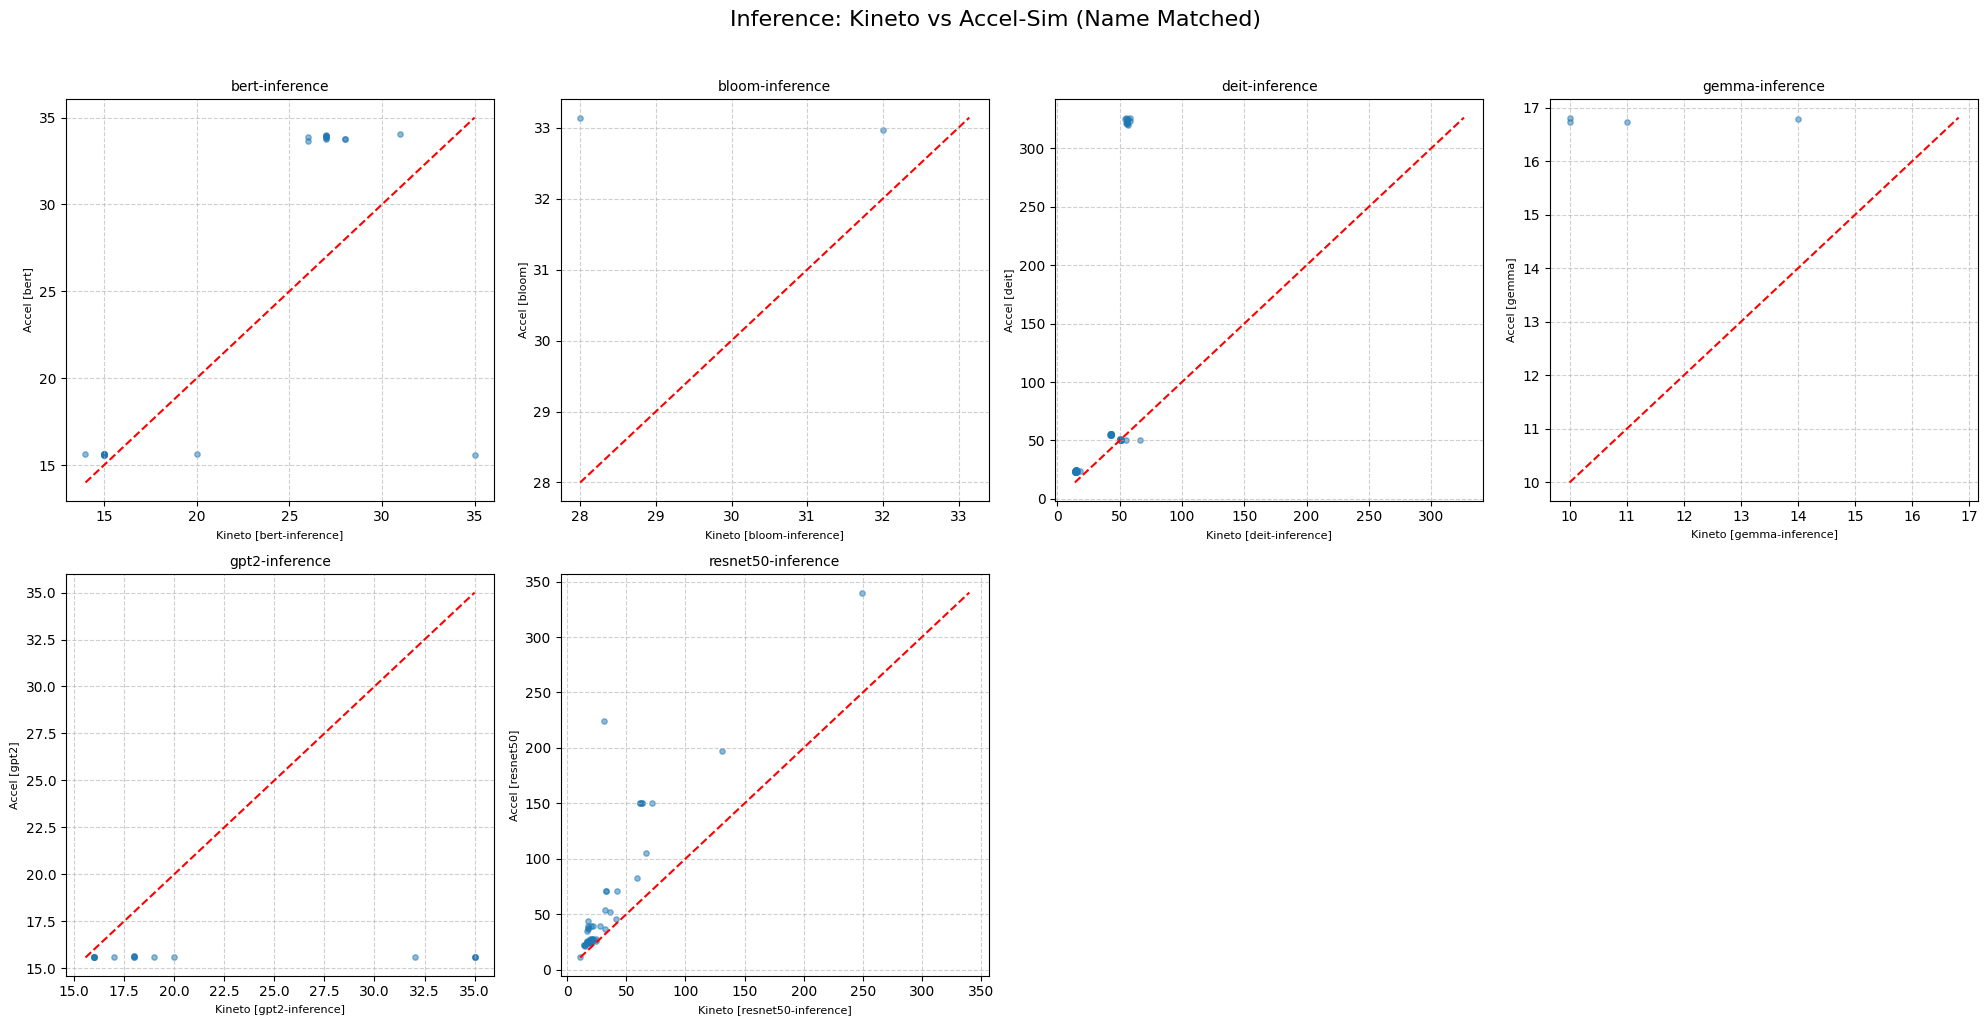

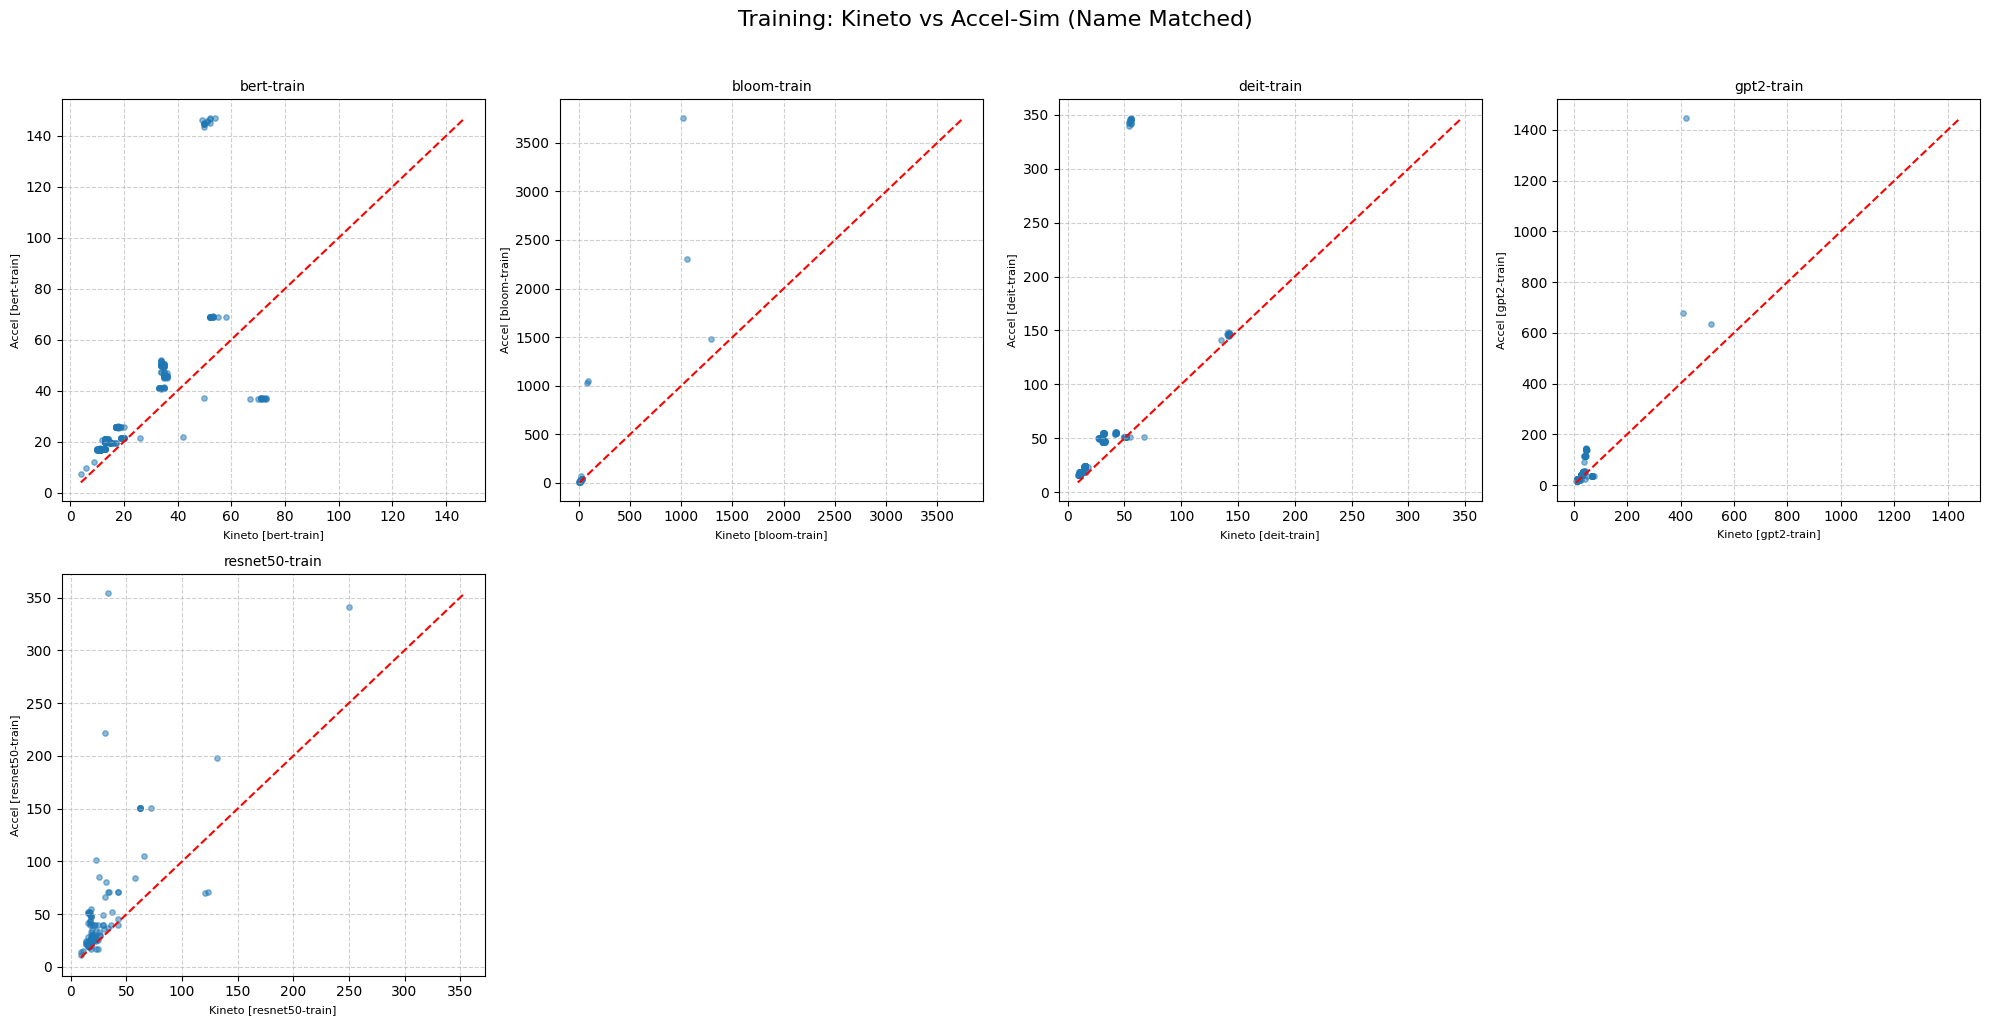

In [33]:
print(f"Searching for models in: {TRACE_ROOT_DIR}")
model_paths = sorted(glob.glob(os.path.join(TRACE_ROOT_DIR, "*")))

inference_results = []
train_results = []

for path in model_paths:
    if os.path.isdir(path):
        result = process_model_trace(path)
        
        if result and len(result['t_times']) > 0:
            if "inference" in result['title']:
                inference_results.append(result)
            else:
                train_results.append(result)

# Generate Plots
print("\n" + "="*50)
plot_grid(inference_results, grid_title="Inference: Kineto vs Accel-Sim (Name Matched)")
plot_grid(train_results, grid_title="Training: Kineto vs Accel-Sim (Name Matched)")

In [34]:
import numpy as np
import polars as pl

def calculate_fit_statistics(data_list, category):
    stats_rows = []
    
    for res in data_list:
        x = res['t_times'] # Kineto (Target)
        y = res['a_times'] # Accel (Prediction)
        
        n = len(x)
        if n < 2:
            continue
            
        # 1. Linear Regression (Slope & Intercept)
        # y = mx + c
        slope, intercept = np.polyfit(x, y, 1)
        
        # 2. R-Squared (Goodness of fit)
        correlation_matrix = np.corrcoef(x, y)
        correlation_xy = correlation_matrix[0, 1]
        r_squared = correlation_xy ** 2
        
        # 3. MAPE (Mean Absolute Percentage Error)
        # Filter out 0 values in denominator to avoid inf
        non_zero_mask = x > 1e-9
        if np.any(non_zero_mask):
            mape = np.mean(np.abs((y[non_zero_mask] - x[non_zero_mask]) / x[non_zero_mask])) * 100
        else:
            mape = 0.0
            
        # 4. RMSE (Root Mean Square Error)
        rmse = np.sqrt(np.mean((y - x) ** 2))
        
        stats_rows.append({
            "Category": category,
            "Model": res['title'],
            "Matched_Kernels": n,
            "R2_Score": round(r_squared, 4),
            "Slope": round(slope, 4),
            "MAPE (%)": round(mape, 2),
            "RMSE (us)": round(rmse, 2)
        })
        
    return stats_rows

# Calculate stats for both lists
all_stats = []
all_stats.extend(calculate_fit_statistics(inference_results, "Inference"))
all_stats.extend(calculate_fit_statistics(train_results, "Training"))

# Convert to Polars DataFrame for nice display
df_stats = pl.DataFrame(all_stats)

# Print
print("-" * 30)
print("Regression & Error Statistics (One-to-One Matched Kernels)")
print("-" * 30)
df_stats

# Optional: Save to CSV
# df_stats.write_csv("regression_stats.csv")

------------------------------
Regression & Error Statistics (One-to-One Matched Kernels)
------------------------------


Category,Model,Matched_Kernels,R2_Score,Slope,MAPE (%),RMSE (us)
str,str,i64,f64,f64,f64,f64
"""Inference""","""bert-inference""",24,0.6179,1.0924,17.26,6.23
"""Inference""","""bloom-inference""",2,1.0,-0.0448,10.68,3.7
"""Inference""","""deit-inference""",84,0.4657,3.8774,105.87,101.31
"""Inference""","""gemma-inference""",4,0.0209,0.0031,51.85,5.75
"""Inference""","""gpt2-inference""",16,0.017,0.0002,20.66,9.53
…,…,…,…,…,…,…
"""Training""","""bert-train""",243,0.451,1.1813,49.19,23.83
"""Training""","""bloom-train""",31,0.7296,2.1143,144.45,594.2
"""Training""","""deit-train""",240,0.3294,1.4251,75.11,65.48
